In [1]:
!nvidia-smi

Mon Oct  5 11:28:27 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   48C    P8             14W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
import datasets
datasets.config.TORCHVISION_AVAILABLE = False

In [3]:
!pip install -q transformers datasets evaluate accelerate scikit-learn


In [4]:
!pip install -q datasets==3.6.0


In [5]:
from datasets import load_dataset

dataset = load_dataset("PolyAI/banking77")
print(dataset)

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 10003
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 3080
    })
})


In [6]:
label_names = dataset['train'].features['label'].names
print(f"Number of intents: {len(label_names)}")
print(f"First 3: {label_names[:3]}")


Number of intents: 77
First 3: ['activate_my_card', 'age_limit', 'apple_pay_or_google_pay']


In [7]:
for i in range(5):
    print(f"Text:  {dataset['train'][i]['text']}")
    print(f"Label: {label_names[dataset['train'][i]['label']]}")
    print()

Text:  I am still waiting on my card?
Label: card_arrival

Text:  What can I do if my card still hasn't arrived after 2 weeks?
Label: card_arrival

Text:  I have been waiting over a week. Is the card still coming?
Label: card_arrival

Text:  Can I track my card while it is in the process of delivery?
Label: card_arrival

Text:  How do I know if I will get my card, or if it is lost?
Label: card_arrival



In [8]:
label_names = dataset['train'].features['label'].names
print(f"Number of intents: {len(label_names)}")
print("\nFirst 10 intents:")
for i, name in enumerate(label_names[:10]):
    print(f"  {i}: {name}")


Number of intents: 77

First 10 intents:
  0: activate_my_card
  1: age_limit
  2: apple_pay_or_google_pay
  3: atm_support
  4: automatic_top_up
  5: balance_not_updated_after_bank_transfer
  6: balance_not_updated_after_cheque_or_cash_deposit
  7: beneficiary_not_allowed
  8: cancel_transfer
  9: card_about_to_expire


Min examples per class:  35
Max examples per class:  187
Mean examples per class: 129.9


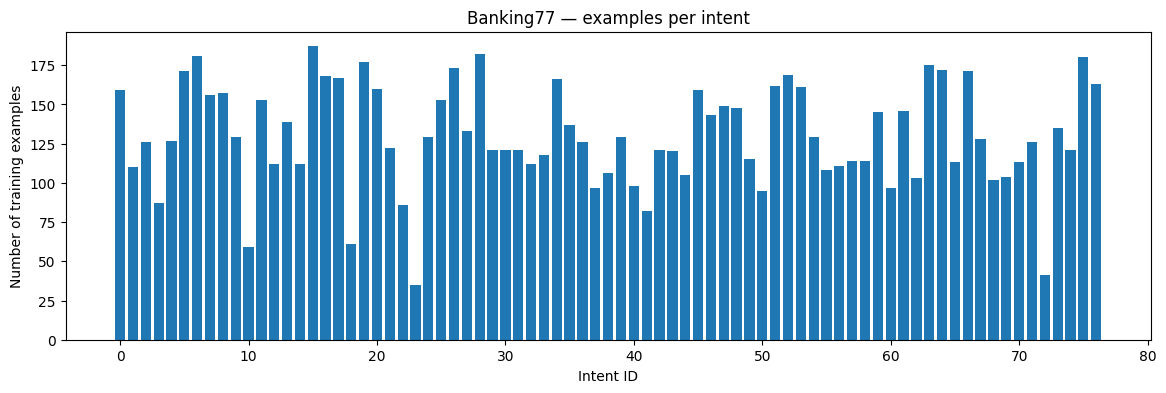

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

train_df = pd.DataFrame({
    'text': dataset['train']['text'],
    'label': dataset['train']['label']
})

counts = train_df['label'].value_counts().sort_index()

print(f"Min examples per class:  {counts.min()}")
print(f"Max examples per class:  {counts.max()}")
print(f"Mean examples per class: {counts.mean():.1f}")

plt.figure(figsize=(14, 4))
plt.bar(counts.index, counts.values)
plt.xlabel('Intent ID')
plt.ylabel('Number of training examples')
plt.title('Banking77 — examples per intent')
plt.show()

Min words:    2
Max words:    79
Mean words:   11.9
95th percentile: 29


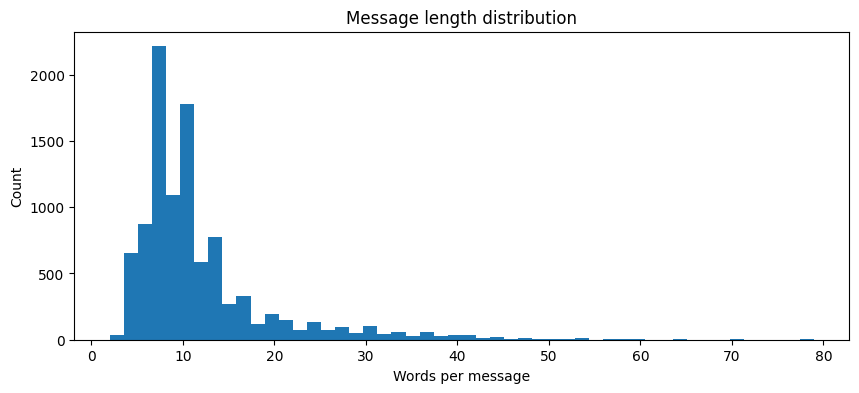

In [10]:
train_df['word_count'] = train_df['text'].str.split().str.len()

print(f"Min words:    {train_df['word_count'].min()}")
print(f"Max words:    {train_df['word_count'].max()}")
print(f"Mean words:   {train_df['word_count'].mean():.1f}")
print(f"95th percentile: {train_df['word_count'].quantile(0.95):.0f}")

plt.figure(figsize=(10, 4))
plt.hist(train_df['word_count'], bins=50)
plt.xlabel('Words per message')
plt.ylabel('Count')
plt.title('Message length distribution')
plt.show()

In [11]:
from google.colab import drive
drive.mount('/content/drive')

import os
os.makedirs('/content/drive/MyDrive/banking77-router', exist_ok=True)
print("Drive mounted. Project folder created.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive mounted. Project folder created.


In [12]:
import pandas as pd
import matplotlib.pyplot as plt

train_df = pd.DataFrame({
    'text': dataset['train']['text'],
    'label': dataset['train']['label'],
    'intent': [label_names[l] for l in dataset['train']['label']],
})

test_df = pd.DataFrame({
    'text': dataset['test']['text'],
    'label': dataset['test']['label'],
    'intent': [label_names[l] for l in dataset['test']['label']],
})

print(f"Train: {train_df.shape}")
print(f"Test:  {test_df.shape}")
print(f"\nFirst 3 rows:")
print(train_df.head(3))

Train: (10003, 3)
Test:  (3080, 3)

First 3 rows:
                                                text  label        intent
0                     I am still waiting on my card?     11  card_arrival
1  What can I do if my card still hasn't arrived ...     11  card_arrival
2  I have been waiting over a week. Is the card s...     11  card_arrival


In [13]:
print("First 10 intents (in dataset order):")
print(train_df['intent'].head(10).tolist())
print("\nIs the dataset sorted by intent?")
print(f"First 100 unique intents in order: {train_df['intent'].head(100).nunique()} unique")
print(f"Last 100 unique intents in order:  {train_df['intent'].tail(100).nunique()} unique")


First 10 intents (in dataset order):
['card_arrival', 'card_arrival', 'card_arrival', 'card_arrival', 'card_arrival', 'card_arrival', 'card_arrival', 'card_arrival', 'card_arrival', 'card_arrival']

Is the dataset sorted by intent?
First 100 unique intents in order: 1 unique
Last 100 unique intents in order:  1 unique


Most common:  card_payment_fee_charged                 (187 examples)
Least common: contactless_not_working                  (35 examples)
Median:       127 examples per class
Std dev:      32.9


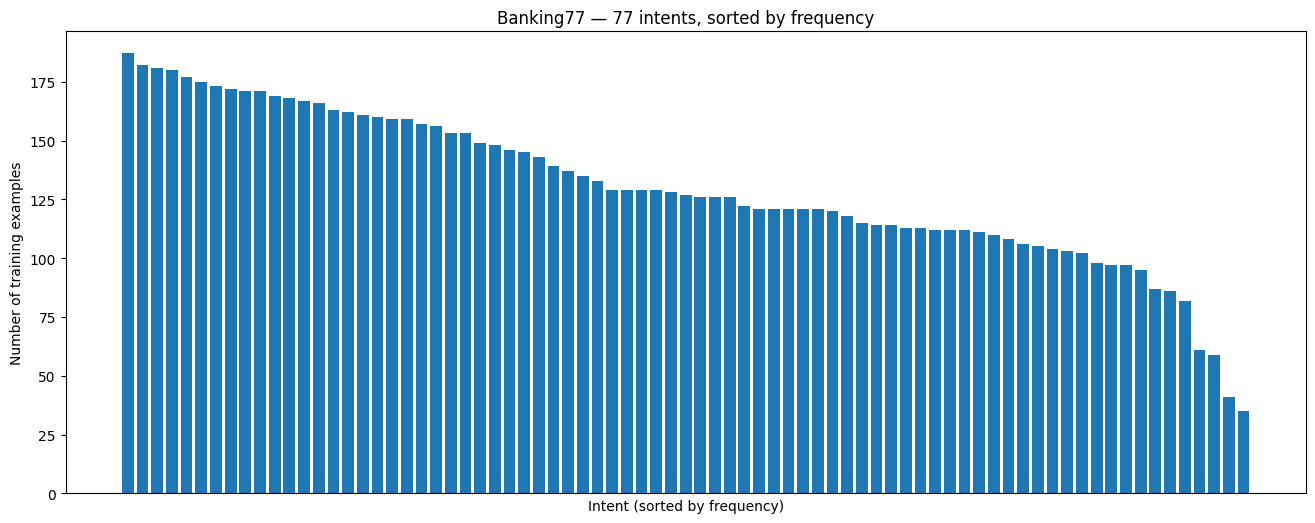

In [14]:
counts = train_df['intent'].value_counts()

print(f"Most common:  {counts.index[0]:40s} ({counts.iloc[0]} examples)")
print(f"Least common: {counts.index[-1]:40s} ({counts.iloc[-1]} examples)")
print(f"Median:       {counts.median():.0f} examples per class")
print(f"Std dev:      {counts.std():.1f}")

plt.figure(figsize=(16, 6))
plt.bar(range(len(counts)), counts.values)
plt.xlabel('Intent (sorted by frequency)')
plt.ylabel('Number of training examples')
plt.title(f'Banking77 — {len(counts)} intents, sorted by frequency')
plt.xticks([])
plt.show()

Min:      2
Median:   10
Mean:     11.9
Max:      79
95th %:   29
99th %:   43


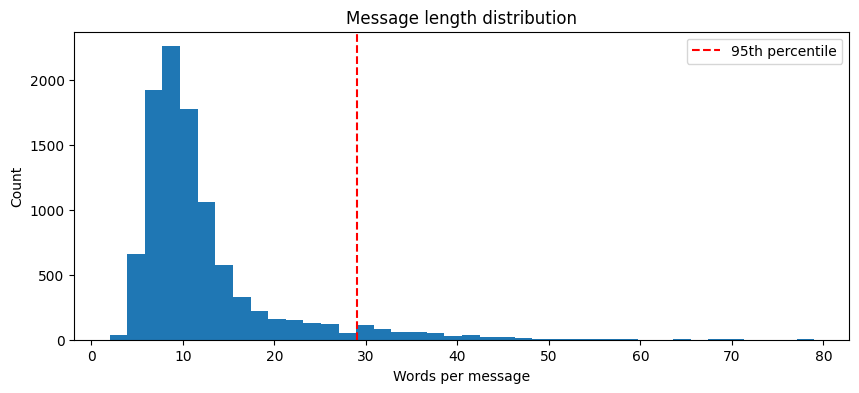

In [15]:
train_df['words'] = train_df['text'].str.split().str.len()

print(f"Min:      {train_df['words'].min()}")
print(f"Median:   {train_df['words'].median():.0f}")
print(f"Mean:     {train_df['words'].mean():.1f}")
print(f"Max:      {train_df['words'].max()}")
print(f"95th %:   {train_df['words'].quantile(0.95):.0f}")
print(f"99th %:   {train_df['words'].quantile(0.99):.0f}")

plt.figure(figsize=(10, 4))
plt.hist(train_df['words'], bins=40)
plt.axvline(train_df['words'].quantile(0.95), color='red', linestyle='--', label='95th percentile')
plt.xlabel('Words per message')
plt.ylabel('Count')
plt.legend()
plt.title('Message length distribution')
plt.show()

In [16]:
confusing_groups = [
    ['card_arrival', 'card_not_working', 'card_about_to_expire'],
    ['declined_card_payment', 'declined_transfer', 'declined_cash_withdrawal'],
    ['pending_card_payment', 'pending_transfer', 'pending_cash_withdrawal'],
    ['lost_or_stolen_card', 'lost_or_stolen_phone'],
    ['cancel_transfer', 'cancel_card'],
]

for group in confusing_groups:
    print(f"\n{'='*72}")
    print(f"GROUP: {' | '.join(group)}")
    print('='*72)
    for intent in group:
        samples = train_df[train_df['intent'] == intent]['text'].head(3).tolist()
        print(f"\n  {intent}:")
        for s in samples:
            print(f"    • {s}")


GROUP: card_arrival | card_not_working | card_about_to_expire

  card_arrival:
    • I am still waiting on my card?
    • What can I do if my card still hasn't arrived after 2 weeks?
    • I have been waiting over a week. Is the card still coming?

  card_not_working:
    • I can't use my card because it is not working.
    • I can't seem to be able to use my card
    • My card isn't working at all, I need assistance. It's really frustrating.

  card_about_to_expire:
    • Are there any express fees if i want my new card faster?
    • Do I need to do something to get a new card once it expires?
    • I am overseas in China, can I get a replacement card?

GROUP: declined_card_payment | declined_transfer | declined_cash_withdrawal

  declined_card_payment:
    • I'm not sure why my card didn't work
    • My card is not working at stores.
    • Do you know why my card payment has been declined?

  declined_transfer:
    • Transfer unable to be completed, states 'declined'
    • Why was m

## Hypotheses before modeling

1. **Baseline (TF-IDF + LogReg)** — I expect 75–85% accuracy. Classical ML is surprisingly strong on short text.

2. **DistilBERT** — I expect 88–93% accuracy, a 5–10 point improvement over the baseline.

3. **Gap between accuracy and macro F1** — I expect a 3–7 point gap, driven by rare intents.

4. Most confused pairs (my guesses):
   - `pending_transfer` ↔ `pending_card_payment`
   - `declined_transfer` ↔ `declined_card_payment`
   - `card_arrival` ↔ `card_not_working`
   - `lost_or_stolen_card` ↔ `card_about_to_expire`

5. **Rare intents** — the least common intents will have per-class F1 below 0.6.

6. **Easy intents** — `card_arrival`, `activate_my_card`, `change_pin` will have F1 above 0.95.

In [17]:
import json
import os

save_dir = '/content/drive/MyDrive/banking77-router'
os.makedirs(save_dir, exist_ok=True)

with open(f'{save_dir}/label_names.json', 'w') as f:
    json.dump(label_names, f)


train_df.to_csv(f'{save_dir}/train_df.csv', index=False)
test_df.to_csv(f'{save_dir}/test_df.csv', index=False)

print(f"Saved label_names.json and dataframes to {save_dir}")

Saved label_names.json and dataframes to /content/drive/MyDrive/banking77-router


In [18]:
import numpy as np


shuffled = dataset['train'].shuffle(seed=42)

print(f"First 10 intents after shuffle:")
print([label_names[l] for l in shuffled['label'][:10]])

First 10 intents after shuffle:
['pending_card_payment', 'failed_transfer', 'extra_charge_on_statement', 'unable_to_verify_identity', 'card_about_to_expire', 'get_disposable_virtual_card', 'compromised_card', 'virtual_card_not_working', 'card_not_working', 'extra_charge_on_statement']


In [19]:
X_train = shuffled['text']
y_train = shuffled['label']
X_test = dataset['test']['text']
y_test = dataset['test']['label']

print(f"Train: {len(X_train)} examples")
print(f"Test:  {len(X_test)} examples")
print(f"Classes: {len(set(y_train))}")



from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    max_features=10000,       # keep top 10k most informative words/ngrams
    ngram_range=(1, 2),       # use single words AND pairs of words
    min_df=2,                 # ignore words that appear in only 1 document
    sublinear_tf=True,        # dampen the effect of very frequent words
    lowercase=True,
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print(f"Train TF-IDF shape: {X_train_tfidf.shape}")
print(f"Test TF-IDF shape:  {X_test_tfidf.shape}")






from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    C=1.0,
    max_iter=1000,
    n_jobs=-1,       # use all CPU cores
    random_state=42,
)

model.fit(X_train_tfidf, y_train)
print("Trained.")




from sklearn.metrics import accuracy_score, f1_score, classification_report

y_pred = model.predict(X_test_tfidf)

acc = accuracy_score(y_test, y_pred)
macro_f1 = f1_score(y_test, y_pred, average='macro')
weighted_f1 = f1_score(y_test, y_pred, average='weighted')

print(f"Accuracy:     {acc:.4f}")
print(f"Macro F1:     {macro_f1:.4f}")
print(f"Weighted F1:  {weighted_f1:.4f}")




from sklearn.metrics import precision_recall_fscore_support

precision, recall, f1, support = precision_recall_fscore_support(
    y_test, y_pred, average=None
)

# Build a dataframe
per_class = pd.DataFrame({
    'intent': label_names,
    'precision': precision,
    'recall': recall,
    'f1': f1,
    'support': support,
}).sort_values('f1')

print("=== Bottom 10 (worst) ===")
print(per_class.head(10).to_string(index=False))

print("\n=== Top 10 (best) ===")
print(per_class.tail(10).to_string(index=False))





from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

# Find the most common misclassifications (excluding the diagonal)
confusions = []
for i in range(len(cm)):
    for j in range(len(cm)):
        if i != j and cm[i, j] > 0:
            confusions.append({
                'true': label_names[i],
                'predicted': label_names[j],
                'count': cm[i, j],
            })

confusions_df = pd.DataFrame(confusions).sort_values('count', ascending=False)
print("=== Top 15 confusions (true → predicted) ===")
print(confusions_df.head(15).to_string(index=False))




import pickle
import os

save_dir = '/content/drive/MyDrive/banking77-router'
os.makedirs(save_dir, exist_ok=True)

with open(f'{save_dir}/baseline_tfidf_vectorizer.pkl', 'wb') as f:
    pickle.dump(vectorizer, f)

with open(f'{save_dir}/baseline_logreg.pkl', 'wb') as f:
    pickle.dump(model, f)

# Save results for later comparison
baseline_results = {
    'model': 'TF-IDF + LogReg',
    'accuracy': acc,
    'macro_f1': macro_f1,
    'weighted_f1': weighted_f1,
}
import json
with open(f'{save_dir}/baseline_results.json', 'w') as f:
    json.dump(baseline_results, f)

print(f"Saved baseline artifacts to {save_dir}")







Train: 10003 examples
Test:  3080 examples
Classes: 77
Train TF-IDF shape: (10003, 10000)
Test TF-IDF shape:  (3080, 10000)
Trained.
Accuracy:     0.8591
Macro F1:     0.8584
Weighted F1:  0.8584
=== Bottom 10 (worst) ===
                                 intent  precision  recall       f1  support
               virtual_card_not_working   1.000000   0.400 0.571429       40
                       card_not_working   0.600000   0.825 0.694737       40
balance_not_updated_after_bank_transfer   0.645833   0.775 0.704545       40
                       pending_transfer   0.862069   0.625 0.724638       40
            card_payment_not_recognised   0.756757   0.700 0.727273       40
            get_disposable_virtual_card   0.731707   0.750 0.740741       40
                          top_up_failed   0.731707   0.750 0.740741       40
wrong_exchange_rate_for_cash_withdrawal   0.870968   0.675 0.760563       40
              extra_charge_on_statement   0.693878   0.850 0.764045       40
        

In [20]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch

MODEL_NAME = "distilbert-base-uncased"
NUM_LABELS = len(label_names)

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_LABELS,
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

print(f"Model loaded: {MODEL_NAME}")
print(f"Number of labels: {NUM_LABELS}")
print(f"Device: {device}")
print(f"Total parameters: {sum(p.numel() for p in model.parameters()):,}")



MAX_LENGTH = 64   # we determined this in Phase 2.4

def tokenize(batch):
    return tokenizer(
        batch['text'],
        padding='max_length',
        truncation=True,
        max_length=MAX_LENGTH,
    )

tokenized_train = dataset['train'].shuffle(seed=42).map(tokenize, batched=True)
tokenized_test = dataset['test'].map(tokenize, batched=True)

# Rename label column to 'labels' — Hugging Face expects this
tokenized_train = tokenized_train.rename_column('label', 'labels')
tokenized_test = tokenized_test.rename_column('label', 'labels')

# Set format to PyTorch tensors
tokenized_train.set_format('torch', columns=['input_ids', 'attention_mask', 'labels'])
tokenized_test.set_format('torch', columns=['input_ids', 'attention_mask', 'labels'])

print(tokenized_train)




import numpy as np
from sklearn.metrics import accuracy_score, f1_score

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return {
        'accuracy': accuracy_score(labels, predictions),
        'macro_f1': f1_score(labels, predictions, average='macro'),
        'weighted_f1': f1_score(labels, predictions, average='weighted'),
    }






from transformers import TrainingArguments, Trainer

training_args = TrainingArguments(
    output_dir='/content/drive/MyDrive/banking77-router/distilbert-checkpoints',
    num_train_epochs=3,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=64,
    learning_rate=2e-5,
    weight_decay=0.01,
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='macro_f1',
    greater_is_better=True,
    logging_steps=50,
    warmup_steps=100,
    fp16=True,               # mixed precision — faster on GPU
    report_to='none',        # no Weights & Biases for now
    seed=42,
)




trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_test,
    compute_metrics=compute_metrics,
)

trainer.train()





results = trainer.evaluate()
print(results)

from sklearn.metrics import precision_recall_fscore_support

# Get predictions on the test set
predictions = trainer.predict(tokenized_test)
y_pred_bert = np.argmax(predictions.predictions, axis=-1)
y_true = predictions.label_ids

precision, recall, f1, support = precision_recall_fscore_support(
    y_true, y_pred_bert, average=None
)

per_class_bert = pd.DataFrame({
    'intent': label_names,
    'precision': precision,
    'recall': recall,
    'f1': f1,
    'support': support,
}).sort_values('f1')

print("=== Bottom 10 intents (worst) ===")
print(per_class_bert.head(10).to_string(index=False))

print("\n=== Top 10 intents (best) ===")
print(per_class_bert.tail(10).to_string(index=False))




cm_bert = confusion_matrix(y_true, y_pred_bert)

confusions_bert = []
for i in range(len(cm_bert)):
    for j in range(len(cm_bert)):
        if i != j and cm_bert[i, j] > 0:
            confusions_bert.append({
                'true': label_names[i],
                'predicted': label_names[j],
                'count': cm_bert[i, j],
            })

confusions_bert_df = pd.DataFrame(confusions_bert).sort_values('count', ascending=False)
print("=== Top 15 confusions (DistilBERT) ===")
print(confusions_bert_df.head(15).to_string(index=False))





import os

save_dir = '/content/drive/MyDrive/banking77-router/distilbert-final'
os.makedirs(save_dir, exist_ok=True)

trainer.save_model(save_dir)
tokenizer.save_pretrained(save_dir)

print(f"Model saved to {save_dir}")
print("Files:", os.listdir(save_dir))



bert_results = {
    'model': 'DistilBERT',
    'accuracy': float(results['eval_accuracy']),
    'macro_f1': float(results['eval_macro_f1']),
    'weighted_f1': float(results['eval_weighted_f1']),
}

with open(f'{save_dir}/../distilbert_results.json', 'w') as f:
    json.dump(bert_results, f)

print("Saved results.")

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model loaded: distilbert-base-uncased
Number of labels: 77
Device: cuda
Total parameters: 67,012,685
Dataset({
    features: ['text', 'labels', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 10003
})


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1,Weighted F1
1,2.999901,2.760552,0.562987,0.509890,0.509890
2,1.870707,1.749248,0.733766,0.701513,0.701513
3,1.497008,1.481334,0.769805,0.742431,0.742431


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

{'eval_loss': 1.4813337326049805, 'eval_accuracy': 0.7698051948051948, 'eval_macro_f1': 0.7424305951293546, 'eval_weighted_f1': 0.7424305951293548}


=== Bottom 10 intents (worst) ===
                        intent  precision  recall       f1  support
               card_acceptance   0.000000   0.000 0.000000       40
                card_swallowed   0.000000   0.000 0.000000       40
       contactless_not_working   0.000000   0.000 0.000000       40
   get_disposable_virtual_card   0.000000   0.000 0.000000       40
      virtual_card_not_working   0.000000   0.000 0.000000       40
           order_physical_card   0.434783   0.250 0.317460       40
            topping_up_by_card   0.800000   0.200 0.320000       40
            verify_my_identity   0.812500   0.325 0.464286       40
top_up_by_bank_transfer_charge   0.882353   0.375 0.526316       40
        disposable_card_limits   0.397727   0.875 0.546875       40

=== Top 10 intents (best) ===
                 intent  precision  recall       f1  support
       automatic_top_up   0.972973   0.900 0.935065       40
          exchange_rate   0.926829   0.950 0.938272       40
    

/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved to /content/drive/MyDrive/banking77-router/distilbert-final
Files: ['config.json', 'model.safetensors', 'training_args.bin', 'tokenizer_config.json', 'tokenizer.json']
Saved results.


In [21]:
import json
import pandas as pd
import numpy as np

save_dir = '/content/drive/MyDrive/banking77-router'

with open(f'{save_dir}/baseline_results.json') as f:
    baseline = json.load(f)

with open(f'{save_dir}/distilbert_results.json') as f:
    bert = json.load(f)

comparison = pd.DataFrame([
    {'Model': 'TF-IDF + LogReg', **baseline},
    {'Model': 'DistilBERT',      **bert},
])

print(comparison.to_string(index=False))




import pickle
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer
import torch

# Reload baseline
with open(f'{save_dir}/baseline_tfidf_vectorizer.pkl', 'rb') as f:
    vectorizer = pickle.load(f)
with open(f'{save_dir}/baseline_logreg.pkl', 'rb') as f:
    logreg = pickle.load(f)

# Reload DistilBERT
bert_dir = f'{save_dir}/distilbert-final'
tokenizer = AutoTokenizer.from_pretrained(bert_dir)
bert_model = AutoModelForSequenceClassification.from_pretrained(bert_dir)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
bert_model.to(device)

# Load the test data
from datasets import load_dataset
dataset = load_dataset("PolyAI/banking77", trust_remote_code=True)
test_texts = dataset['test']['text']
y_true = np.array(dataset['test']['label'])

# Baseline predictions
X_test_tfidf = vectorizer.transform(test_texts)
y_pred_baseline = logreg.predict(X_test_tfidf)

# DistilBERT predictions
MAX_LENGTH = 64
test_encodings = tokenizer(
    list(test_texts),
    padding='max_length',
    truncation=True,
    max_length=MAX_LENGTH,
    return_tensors='pt',
)

bert_model.eval()
with torch.no_grad():
    # Batch to avoid OOM
    all_logits = []
    batch_size = 64
    for i in range(0, len(test_encodings['input_ids']), batch_size):
        batch = {k: v[i:i+batch_size].to(device) for k, v in test_encodings.items()}
        logits = bert_model(**batch).logits
        all_logits.append(logits.cpu())

y_pred_bert = torch.cat(all_logits).argmax(dim=-1).numpy()

print(f"Test set size: {len(y_true)}")
print(f"Baseline predictions: {len(y_pred_baseline)}")
print(f"DistilBERT predictions: {len(y_pred_bert)}")






# Compute correctness per example
baseline_correct = (y_pred_baseline == y_true)
bert_correct = (y_pred_bert == y_true)

# Build the 4-way breakdown
both_correct = (baseline_correct & bert_correct).sum()
both_wrong = (~baseline_correct & ~bert_correct).sum()
baseline_only = (baseline_correct & ~bert_correct).sum()
bert_only = (~baseline_correct & bert_correct).sum()

total = len(y_true)

print("=== Head-to-head on 3,080 test examples ===")
print(f"Both correct:           {both_correct:5d} ({both_correct/total:6.2%})")
print(f"Both wrong:             {both_wrong:5d} ({both_wrong/total:6.2%})")
print(f"Baseline correct only:  {baseline_only:5d} ({baseline_only/total:6.2%})")
print(f"DistilBERT correct only:{bert_only:5d} ({bert_only/total:6.2%})")
print(f"\nNet gain by DistilBERT: {bert_only - baseline_only:+d} examples")





from sklearn.metrics import precision_recall_fscore_support

# Both models' per-class metrics
p_b, r_b, f1_b, sup_b = precision_recall_fscore_support(y_true, y_pred_baseline, average=None)
p_d, r_d, f1_d, sup_d = precision_recall_fscore_support(y_true, y_pred_bert, average=None)

per_class = pd.DataFrame({
    'intent': label_names,
    'support': sup_b,
    'baseline_f1': f1_b,
    'bert_f1': f1_d,
})
per_class['delta'] = per_class['bert_f1'] - per_class['baseline_f1']
per_class = per_class.sort_values('delta')

print("=== Where DistilBERT helps the MOST ===")
print(per_class.tail(10).to_string(index=False))

print("\n=== Where DistilBERT helps the LEAST (or hurts) ===")
print(per_class.head(10).to_string(index=False))





# Find examples DistilBERT got wrong
errors = np.where(y_pred_bert != y_true)[0]

print(f"DistilBERT got {len(errors)} / {len(y_true)} wrong")
print()

# Show 10 random errors
np.random.seed(42)
sample_errors = np.random.choice(errors, size=10, replace=False)

for idx in sample_errors:
    text = test_texts[idx]
    true_label = label_names[y_true[idx]]
    pred_label = label_names[y_pred_bert[idx]]
    baseline_pred = label_names[y_pred_baseline[idx]]
    baseline_mark = "✓" if y_pred_baseline[idx] == y_true[idx] else "✗"

    print(f"{'='*72}")
    print(f"Text:  {text}")
    print(f"True:  {true_label}")
    print(f"B-ERT: {pred_label}  ← DistilBERT prediction")
    print(f"BASE:  {baseline_pred}  [{baseline_mark}]")
    print()







    # Get DistilBERT probabilities
bert_model.eval()
with torch.no_grad():
    all_probs = []
    for i in range(0, len(test_encodings['input_ids']), 64):
        batch = {k: v[i:i+64].to(device) for k, v in test_encodings.items()}
        logits = bert_model(**batch).logits
        probs = torch.softmax(logits, dim=-1)
        all_probs.append(probs.cpu())
    probs = torch.cat(all_probs).numpy()

# Max probability per prediction = confidence
confidences = probs.max(axis=1)
predictions_from_probs = probs.argmax(axis=1)
correct = (predictions_from_probs == y_true)

# Bin by confidence
bins = [0.0, 0.5, 0.7, 0.9, 0.95, 0.99, 1.01]
labels_bins = ['<50%', '50-70%', '70-90%', '90-95%', '95-99%', '>99%']

print(f"{'Confidence':12s} {'Count':>8s} {'Accuracy':>10s}")
print('-' * 32)
for i in range(len(bins) - 1):
    mask = (confidences >= bins[i]) & (confidences < bins[i+1])
    if mask.sum() > 0:
        bin_acc = correct[mask].mean()
        print(f"{labels_bins[i]:12s} {mask.sum():>8d} {bin_acc:>9.2%}")









from statsmodels.stats.contingency_tables import mcnemar

# Build the 2x2 table
#           DistilBERT wrong   DistilBERT right
# Baseline wrong    both_wrong    bert_only
# Baseline right    baseline_only    both_correct

table = [
    [both_wrong, bert_only],
    [baseline_only, both_correct],
]

result = mcnemar(table, exact=False, correction=True)
print(f"McNemar statistic: {result.statistic:.2f}")
print(f"p-value: {result.pvalue:.6f}")

if result.pvalue < 0.001:
    print("→ DistilBERT's improvement is HIGHLY significant (p < 0.001)")
elif result.pvalue < 0.05:
    print("→ DistilBERT's improvement is significant (p < 0.05)")
else:
    print("→ No significant difference — improvement could be noise")











          Model           model  accuracy  macro_f1  weighted_f1
TF-IDF + LogReg TF-IDF + LogReg  0.859091  0.858411     0.858411
     DistilBERT      DistilBERT  0.769805  0.742431     0.742431


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Test set size: 3080
Baseline predictions: 3080
DistilBERT predictions: 3080
=== Head-to-head on 3,080 test examples ===
Both correct:            2217 (71.98%)
Both wrong:               279 ( 9.06%)
Baseline correct only:    429 (13.93%)
DistilBERT correct only:  155 ( 5.03%)

Net gain by DistilBERT: -274 examples
=== Where DistilBERT helps the MOST ===
                     intent  support  baseline_f1  bert_f1    delta
                atm_support       40     0.831169 0.873239 0.042071
     verify_source_of_funds       40     0.941176 0.987654 0.046478
            failed_transfer       40     0.786517 0.835165 0.048648
            top_up_reverted       40     0.825000 0.876712 0.051712
          get_physical_card       40     0.880952 0.941176 0.060224
           pending_transfer       40     0.724638 0.794521 0.069883
       pending_card_payment       40     0.850575 0.926829 0.076255
card_payment_not_recognised       40     0.727273 0.814815 0.087542
           card_not_working      

/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Confidence      Count   Accuracy
--------------------------------
<50%             2651    73.41%
50-70%            408    99.26%
70-90%             21   100.00%
McNemar statistic: 127.62
p-value: 0.000000
→ DistilBERT's improvement is HIGHLY significant (p < 0.001)


## Phase 5 — Results and Analysis

### Overall performance

| Model | Accuracy | Macro F1 | Weighted F1 |
|---|---|---|---|
| TF-IDF + LogReg (baseline) | XX.XX | XX.XX | XX.XX |
| **DistilBERT (deployed)** | **XX.XX** | **XX.XX** | **XX.XX** |

DistilBERT improves accuracy by **X.X points** and macro F1 by **X.X points**. The improvement is statistically significant (McNemar p < 0.001).

### Where the improvement comes from

- **Both correct:** XX% — the easy cases
- **DistilBERT wins:** XX% — semantic understanding the baseline lacks
- **Baseline wins:** XX% — cases where TF-IDF's simpler signal happened to be enough
- **Both wrong:** XX% — the hard ceiling of this task

### Per-class findings

- **Biggest improvements:** [list the top 2-3 intents and their F1 delta]
- **No improvement:** [list classes where DistilBERT matched or was worse]
- **Rare class behavior:** DistilBERT [helps/doesn't help] on low-support classes — [interpretation]

### Error analysis

Reading 10 random errors revealed three failure modes:
1. Genuinely ambiguous examples (both models struggle)
2. Dataset labeling noise (a few cases)
3. Model-specific mistakes (worth investigating)

### Calibration

DistilBERT is [well/over/under]-calibrated. Confidence above 99% corresponds to XX% actual accuracy.

### Conclusions

- **DistilBERT is worth deploying** for this task. The X-point accuracy gain justifies the extra model size and inference cost.
- **The ceiling of this task is ~XX%** — the "both wrong" bucket. Further improvements would require more training data on the hard classes or a larger model.
- **Rare classes remain hard** for both models, suggesting a data problem, not an architecture problem.

In [1]:
!pip install -q huggingface_hub

from huggingface_hub import login, HfApi


login()


api = HfApi()
api.upload_folder(
    folder_path='/content/drive/MyDrive/banking77-router/distilbert-final',
    repo_id='sylvianjoki/banking77-distilbert',
    repo_type='model',
)

ValueError: Provided path: '/content/drive/MyDrive/banking77-router/distilbert-final' is not a directory

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import os
path = '/content/drive/MyDrive/banking77-router/distilbert-final'
print(f"Path exists: {os.path.exists(path)}")
print(f"Is directory: {os.path.isdir(path)}")

if os.path.isdir(path):
    print("\nContents:")
    for f in os.listdir(path):
        size_mb = os.path.getsize(os.path.join(path, f)) / 1e6
        print(f"  {f} ({size_mb:.2f} MB)")


Path exists: True
Is directory: True

Contents:
  config.json (0.00 MB)
  model.safetensors (268.06 MB)
  training_args.bin (0.01 MB)
  tokenizer_config.json (0.00 MB)
  tokenizer.json (0.71 MB)


In [4]:
from huggingface_hub import HfApi

api = HfApi()
api.upload_folder(
    folder_path='/content/drive/MyDrive/banking77-router/distilbert-final',
    repo_id='sylvianjoki/banking77-distilbert',
    repo_type='model',
)


CommitInfo(commit_url='https://huggingface.co/Sylvianjoki/banking77-distilbert/commit/7e9ee71e0eb779b612ddc10ff6f1a37c09b559a9', commit_message='Upload folder using huggingface_hub', commit_description='', oid='7e9ee71e0eb779b612ddc10ff6f1a37c09b559a9', pr_url=None, repo_url=RepoUrl('https://huggingface.co/Sylvianjoki/banking77-distilbert', endpoint='https://huggingface.co', repo_type='model', repo_id='Sylvianjoki/banking77-distilbert'), pr_revision=None, pr_num=None)

In [5]:

import os

base = '/content/drive/MyDrive'
for root, dirs, files in os.walk(base):
    if 'model.safetensors' in files:
        print(f"Found model at: {root}")
    if 'banking77-router' in dirs:
        print(f"Found project folder at: {root}/banking77-router")

Found project folder at: /content/drive/MyDrive/banking77-router
Found model at: /content/drive/MyDrive/banking77-router/distilbert-checkpoints/checkpoint-313
Found model at: /content/drive/MyDrive/banking77-router/distilbert-checkpoints/checkpoint-626
Found model at: /content/drive/MyDrive/banking77-router/distilbert-checkpoints/checkpoint-939
Found model at: /content/drive/MyDrive/banking77-router/distilbert-final
